# XGBoost + ADASYN — Data-level vs Algorithm-level Imbalance Handling for `sii`

**Question.** Module 2 found **XGBoost** to be the strongest classifier for `sii`, and Module 1 (after fixing a resample-before-CV leak) found **ADASYN** to be the best-performing imbalanced-learning technique. This notebook pairs the two and asks a single, focused question:

> Does **data-level** rebalancing (ADASYN oversampling) beat the **algorithm-level** rebalancing (`class_weight`-style balanced sample weights) that the Module 2 models already use — on our strongest model?

We compare two configurations under an **identical** protocol (same split, seed, hyperparameter grid, `n_iter`, and `f1_macro` scoring):

| Config | Imbalance handling | Resampling |
|---|---|---|
| **B — Weighted (reference)** | balanced sample weights | none |
| **C — ADASYN** | none | ADASYN oversampling |

**Two design points worth stating up front:**
1. **No leakage.** ADASYN runs *inside* each CV fold (an `imblearn` pipeline), never on the validation fold or the test set — the same fix applied in `module_1_v2`. Its synthetic samples are therefore never validated against.
2. **Why no weights on top of ADASYN.** ADASYN already balances the classes, so balanced weights computed afterwards are ≈ uniform and contribute almost nothing. We therefore drop them in config C and let ADASYN be the *sole* imbalance mechanism — a clean contrast against the weights-only baseline B.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
)
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Data Loading

In [2]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col="id")

# PCIAT_Total is excluded — it is the source of `sii` (perfect leakage) and is reserved for regression.
feature_columns = [col for col in df.columns if col not in ("sii", "PCIAT-PCIAT_Total")]
X = df[feature_columns]
y = df["sii"].astype(int)

class_names = ["None (0)", "Mild (1)", "Moderate (2)", "Severe (3)"]
num_classes = len(class_names)

print(f"Shape: {df.shape}")
print("\nClass distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(1))

Shape: (8193, 20)

Class distribution (%):
sii
0    69.1
1    18.7
2    11.2
3     1.0
Name: proportion, dtype: float64


## 2. Train / Test Split

Identical split to every other Module 2 notebook (`test_size=0.2`, `stratify=y`, `random_state=42`) so results are directly comparable to the standalone `xgboost.ipynb`.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())

Train: 6554 | Test: 1639

Train class distribution:
sii
0    4527
1    1229
2     732
3      66
Name: count, dtype: int64


## 3. The Two Configurations

Both configs share the same XGBoost backbone, hyperparameter grid, and tuning budget — the *only* thing that changes is how class imbalance is addressed.

- **`StandardScaler`** is included in both pipelines. XGBoost is scale-invariant (tree splits don't care about feature scale), so it has no effect on the classifier — but **ADASYN is distance-based** (it synthesises minority points from k-nearest neighbours), so scaling is required for its neighbour search to be meaningful (a feature like `BIA-BIA_DEE` ~1500 would otherwise dominate `Basic_Demos-Sex` ∈ {0,1}).
- **Config B** uses `BalancedXGB`, a thin `XGBClassifier` subclass that computes balanced sample weights from the training labels at `fit` time — reproducing the imbalance handling of the standalone `xgboost.ipynb`, but recomputed *per CV fold*.
- **Config C** uses a plain `XGBClassifier` with **ADASYN** inserted before it. Because the resampler lives inside the pipeline, `RandomizedSearchCV` applies it to the training portion of each fold only.

In [4]:
class BalancedXGB(XGBClassifier):
    """XGBoost that injects balanced per-sample weights at fit time.

    Used for config B (algorithm-level imbalance handling). Computing the
    weights inside fit() means they are recomputed on each CV fold's training
    labels, with no leakage from the validation fold.
    """
    def fit(self, X, y, **kwargs):
        sw = compute_sample_weight(class_weight="balanced", y=y)
        return super().fit(X, y, sample_weight=sw, **kwargs)


xgb_kwargs = dict(
    objective="multi:softprob",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="mlogloss",
)

configs = {
    "B — Weighted (reference)": ImbPipeline([
        ("scaler", StandardScaler()),
        ("clf", BalancedXGB(**xgb_kwargs)),
    ]),
    "C — ADASYN": ImbPipeline([
        ("scaler", StandardScaler()),
        ("adasyn", ADASYN(random_state=RANDOM_STATE, n_neighbors=5)),
        ("clf", XGBClassifier(**xgb_kwargs)),
    ]),
}

# Same grid as the standalone xgboost.ipynb, addressed to the pipeline's "clf" step.
param_distributions = {
    "clf__n_estimators":     [200, 400, 600, 800],
    "clf__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth":        [3, 4, 5, 6],
    "clf__min_child_weight": [1, 3, 5],
    "clf__subsample":        [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0],
    "clf__gamma":            [0, 0.5, 1.0],
    "clf__reg_lambda":       [1.0, 2.0, 5.0],
}

N_ITER = 40
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 4. Hyperparameter Tuning

`RandomizedSearchCV` with **40 sampled configurations**, **5-fold stratified CV**, scored on **macro F1** — the right metric under imbalance and the same objective used across Module 2. For config C the ADASYN step is re-run on every fold of every candidate, so this cell is the slow one.

In [5]:
searches = {}
for name, pipe in configs.items():
    print(f"\n{'='*70}\nTuning | {name}\n{'='*70}")
    search = RandomizedSearchCV(
        pipe, param_distributions, n_iter=N_ITER, cv=skf,
        scoring="f1_macro", n_jobs=-1, refit=True,
        random_state=RANDOM_STATE, verbose=1,
    )
    search.fit(X_train, y_train)
    searches[name] = search
    best = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    print(f"Best params: {best}")
    print(f"Best CV F1 (macro): {search.best_score_:.4f}")


Tuning | B — Weighted (reference)
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'subsample': 0.8, 'reg_lambda': 5.0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}
Best CV F1 (macro): 0.3362

Tuning | C — ADASYN
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'subsample': 1.0, 'reg_lambda': 5.0, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV F1 (macro): 0.3270


## 5. Test-set Comparison

In [6]:
rows = {}
preds = {}
for name, search in searches.items():
    y_pred = search.best_estimator_.predict(X_test)
    preds[name] = y_pred
    per_cls_rec = recall_score(y_test, y_pred, average=None, labels=range(num_classes), zero_division=0)
    rows[name] = {
        "CV F1 (macro)":  round(search.best_score_, 4),
        "Accuracy":       round(accuracy_score(y_test, y_pred), 4),
        "F1 (macro)":     round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall (macro)": round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "F1 (weighted)":  round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "Severe recall":  round(per_cls_rec[3], 4),
    }

comparison = pd.DataFrame(rows).T
comparison.index.name = "Configuration"
comparison

,CV F1 (macro),Accuracy,F1 (macro),Recall (macro),F1 (weighted),Severe recall
Configuration,,,,,,
B — Weighted (reference),0.3362,0.5418,0.3375,0.3625,0.5725,0.0588
C — ADASYN,0.3270,0.5815,0.3127,0.3294,0.5880,0.1176


In [7]:
for name, y_pred in preds.items():
    print(f"\n{'='*70}\n{name}\n{'='*70}")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


B — Weighted (reference)
              precision    recall  f1-score   support

    None (0)       0.78      0.62      0.69      1132
    Mild (1)       0.31      0.39      0.35       307
Moderate (2)       0.23      0.39      0.29       183
  Severe (3)       0.02      0.06      0.03        17

    accuracy                           0.54      1639
   macro avg       0.33      0.36      0.34      1639
weighted avg       0.62      0.54      0.57      1639


C — ADASYN
              precision    recall  f1-score   support

    None (0)       0.75      0.75      0.75      1132
    Mild (1)       0.32      0.19      0.23       307
Moderate (2)       0.21      0.27      0.23       183
  Severe (3)       0.02      0.12      0.03        17

    accuracy                           0.58      1639
   macro avg       0.32      0.33      0.31      1639
weighted avg       0.60      0.58      0.59      1639



### Confusion Matrices

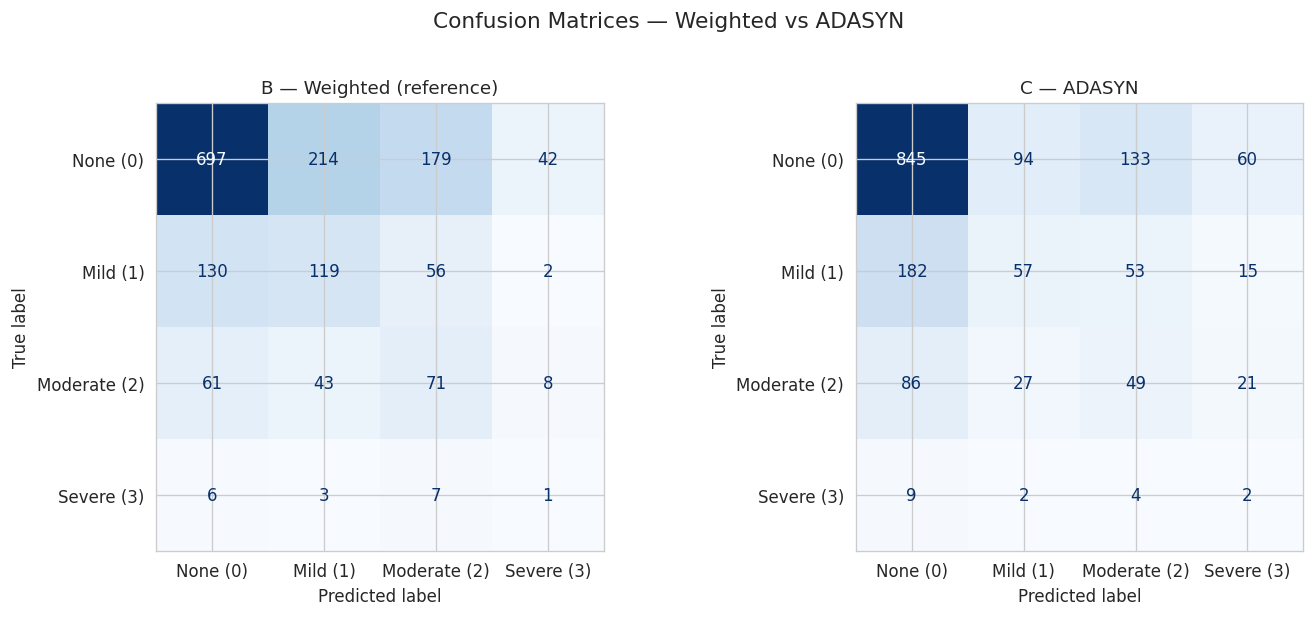

In [8]:
fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 5))
for ax, (name, y_pred) in zip(np.atleast_1d(axes), preds.items()):
    cm = confusion_matrix(y_test, y_pred, labels=range(num_classes))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=11)
plt.suptitle("Confusion Matrices — Weighted vs ADASYN", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Grouped metric comparison

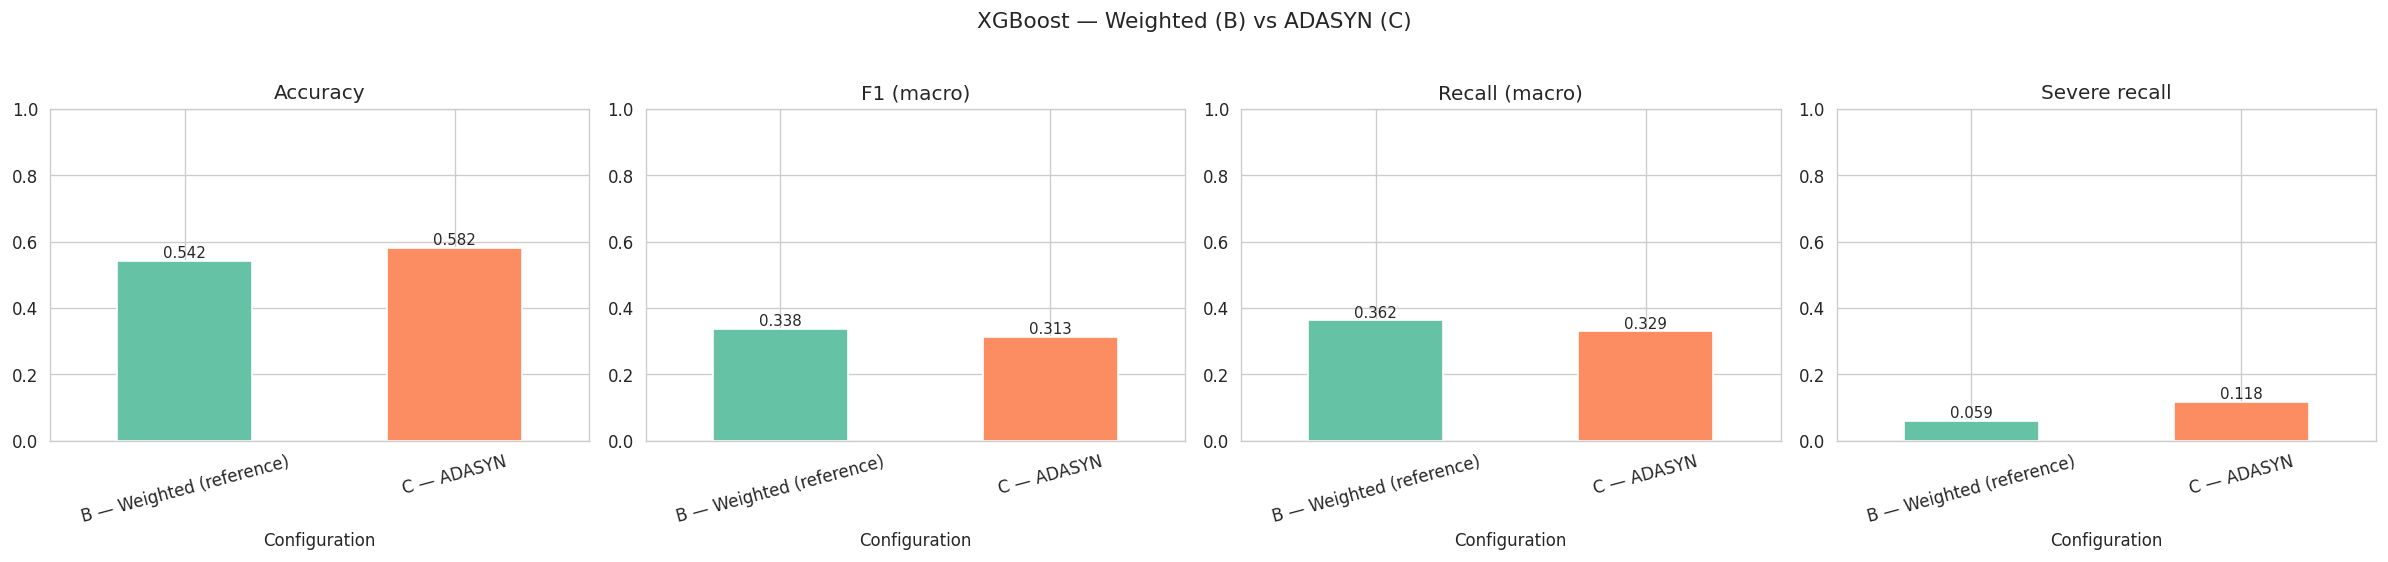

In [9]:
metrics_to_plot = ["Accuracy", "F1 (macro)", "Recall (macro)", "Severe recall"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 4.5))
for ax, metric in zip(axes, metrics_to_plot):
    comparison[metric].plot(kind="bar", ax=ax, color=sns.color_palette("Set2", len(comparison)), rot=15)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("XGBoost — Weighted (B) vs ADASYN (C)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 6. ROC Curves (One-vs-Rest)

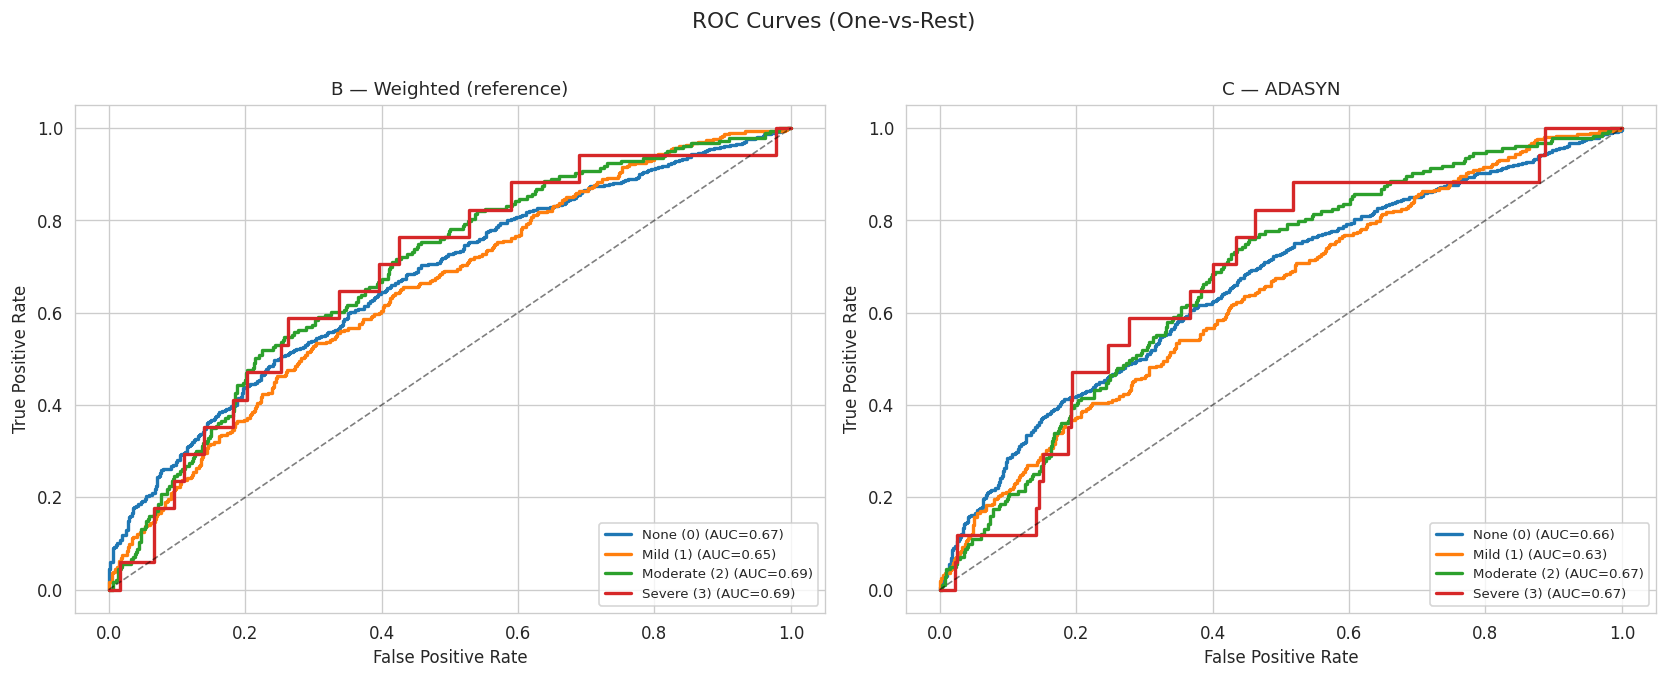

In [10]:
y_test_bin = label_binarize(y_test, classes=range(num_classes))
colors_roc = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(1, len(searches), figsize=(7 * len(searches), 5.5))
for ax, (name, search) in zip(np.atleast_1d(axes), searches.items()):
    y_score = search.best_estimator_.predict_proba(X_test)
    for i, (cls, color) in enumerate(zip(class_names, colors_roc)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(name, fontsize=11); ax.legend(loc="lower right", fontsize=8)
plt.suptitle("ROC Curves (One-vs-Rest)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Feature Importance — ADASYN model

XGBoost's gain-based importance for config C. Worth checking whether oversampling the minority classes shifts which features the model relies on, relative to the weighted baseline.

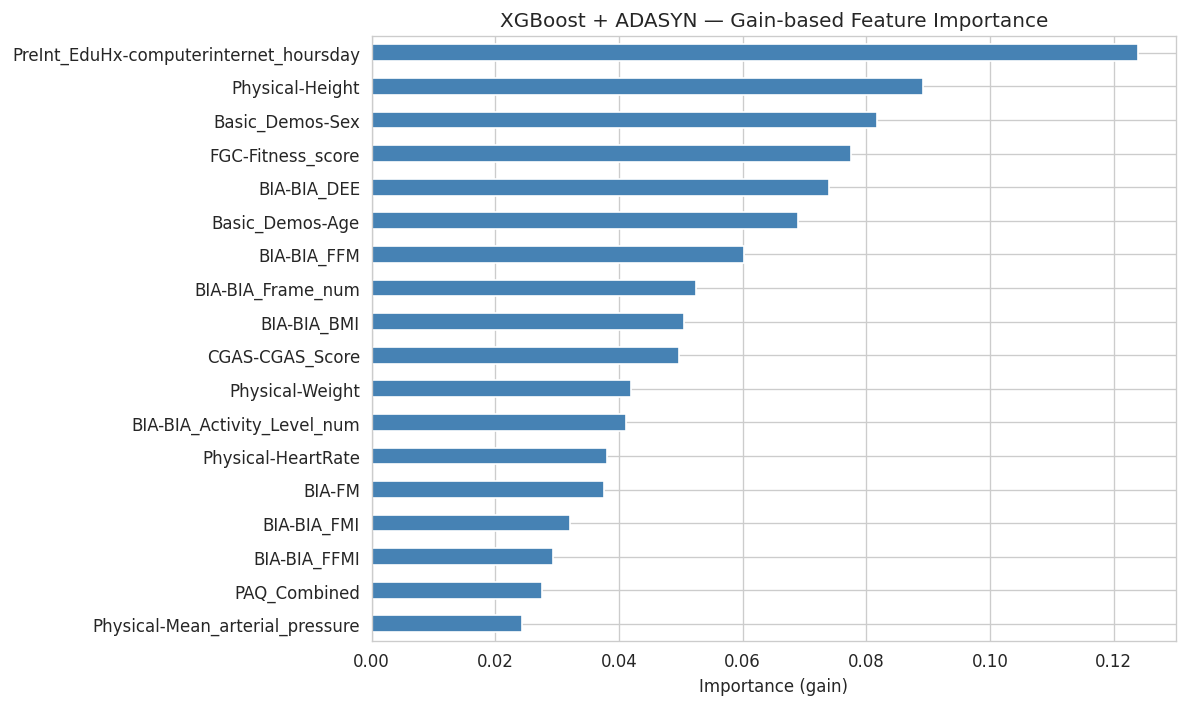

In [11]:
best_c = searches["C — ADASYN"].best_estimator_.named_steps["clf"]
importances = pd.Series(best_c.feature_importances_, index=feature_columns).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("XGBoost + ADASYN — Gain-based Feature Importance")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

## 8. Conclusions

Read the comparison table and the per-class reports together with these questions in mind:

- **Did data-level beat algorithm-level?** Compare **C (ADASYN)** vs **B (weighted)** on **macro F1** — the headline metric. In Module 1 (Decision Tree) ADASYN beat the weighted baseline only marginally on macro F1; the expectation here is similar — a small change at best, possibly a shift in the *accuracy ↔ recall* trade-off rather than a clear win.
- **What happened to the Severe class?** This is the real test. Track `Severe recall`: both mechanisms try to rescue the 17-sample minority class, but ADASYN does it by fabricating ~4.5k synthetic Severe points (a 68× extrapolation), while weighting does it by re-scaling the loss. Note which catches more Severe cases and at what cost to accuracy.
- **CV ↔ test agreement.** Because ADASYN now runs inside the folds, config C's CV macro-F1 should track its test macro-F1 — unlike the inflated ~0.74 seen with the leaky pipeline in Module 1.
- **Caveats.** ADASYN interpolates over a feature space that already contains instructor-injected synthetic samples, and its 68× blow-up of the Severe class risks fabricating physiologically implausible profiles. A clean negative result here — *"data-level oversampling does not improve our strongest model over simple class weighting"* — is itself a legitimate and reportable finding.